In [35]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import time
import datetime
import lecilab_behavior_analysis.utils as utils


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
# see the available projects
tv_projects = utils.get_server_projects()
for i, p in enumerate(tv_projects):
    print(f"[{i}] {p}")

[0] auditory_escape_data
[1] cate_task_data
[2] COT_cannula_data
[3] COT_cannula_GAD2_data
[4] COT_unilateral_sound_data
[5] frequency_vs_location_data
[6] frequency_vs_locationPureTone_data
[7] retrocre_data
[8] sound_localization_paradigm_data
[9] Village_Towers_Task_data
[10] wireless_opto_data


In [37]:
# select a project
project = tv_projects[8]
print(f"Selected project: {project}")

Selected project: sound_localization_paradigm_data


In [38]:
# see the available animals
animals = utils.get_animals_in_project(project)
print(animals)

['test1']


In [39]:
# select an animal and sync the data
mouse = 'test1'
local_path = Path(utils.get_outpath()) / Path(project) / Path("sessions")
# create the directory if it doesn't exist
local_path.mkdir(parents=True, exist_ok=True)
utils.rsync_cluster_data(
    project_name=project,
    file_path="sessions/{}".format(mouse),
    local_path=str(local_path),
    credentials=utils.get_idibaps_cluster_credentials(),
)

receiving incremental file list
test1/
test1/test1.csv
test1/test1_SoundLocalization_20260904_152525.csv
test1/test1_SoundLocalization_20260904_152525.json
test1/test1_SoundLocalization_20260904_152525_IMU.parquet
test1/test1_SoundLocalization_20260904_152525_RAW.csv
test1/test1_SoundLocalization_20260904_152753.csv
test1/test1_SoundLocalization_20260904_152753.json
test1/test1_SoundLocalization_20260904_152753_IMU.parquet
test1/test1_SoundLocalization_20260904_152753_RAW.csv

sent 283 bytes  received 647,852 bytes  259,254.00 bytes/sec
total size is 1,888,867  speedup is 2.91


True

In [40]:
# see the files in the local session directory
files = list(Path(local_path / mouse).glob("*"))
for f in files:
    print(f.name)

test1.csv
test1_SoundLocalization_20260903_154922_IMU.parquet
test1_SoundLocalization_20260903_155211.csv
test1_SoundLocalization_20260903_155211.json
test1_SoundLocalization_20260903_155211_IMU.parquet
test1_SoundLocalization_20260903_155211_RAW.csv
test1_SoundLocalization_20260903_160032_IMU.parquet
test1_SoundLocalization_20260903_160658_IMU.parquet
test1_SoundLocalization_20260903_160833_IMU.parquet
test1_SoundLocalization_20260903_160956_IMU.parquet
test1_SoundLocalization_20260903_161540_IMU.parquet
test1_SoundLocalization_20260903_162759.csv
test1_SoundLocalization_20260903_162759.json
test1_SoundLocalization_20260903_162759_IMU.parquet
test1_SoundLocalization_20260903_162759_RAW.csv
test1_SoundLocalization_20260904_152525.csv
test1_SoundLocalization_20260904_152525.json
test1_SoundLocalization_20260904_152525_IMU.parquet
test1_SoundLocalization_20260904_152525_RAW.csv
test1_SoundLocalization_20260904_152753.csv
test1_SoundLocalization_20260904_152753.json
test1_SoundLocalizatio

In [41]:
# select a specific session
session_date = "20260904_152753"
# see the datasets for that session
valid_files = [f for f in files if session_date in f.name]
for f in valid_files:
    print(f.name)

test1_SoundLocalization_20260904_152753.csv
test1_SoundLocalization_20260904_152753.json
test1_SoundLocalization_20260904_152753_IMU.parquet
test1_SoundLocalization_20260904_152753_RAW.csv


In [42]:
# load them
sessiondf = pd.read_csv([f for f in valid_files if f.name.endswith(f"{session_date}.csv")][0], sep=";")
imu = pd.read_parquet([f for f in valid_files if f.name.endswith(f"{session_date}_IMU.parquet")][0])

In [51]:
sessiondf

,date,trial,subject,task,system_name,TRIAL_START,TRIAL_END,button_click,sound,ordered_list_of_events,sound_side,intensity,sound_duration,water,run_mode
0,2026-09-04 15:27:53,1,test1,SoundLocalization,village12,1.788528e+09,1.788528e+09,[1788528488.1391],[1788528488.1394],"['button_click', 'sound']",left,70,0.15,0,Manual
1,2026-09-04 15:27:53,2,test1,SoundLocalization,village12,1.788528e+09,1.788528e+09,[1788528492.7167],[1788528492.7172],"['button_click', 'sound']",left,60,0.15,0,Manual
2,2026-09-04 15:27:53,3,test1,SoundLocalization,village12,1.788528e+09,1.788528e+09,[1788528497.3203],[1788528497.3205],"['button_click', 'sound']",left,70,0.15,0,Manual
3,2026-09-04 15:27:53,4,test1,SoundLocalization,village12,1.788528e+09,1.788529e+09,[1788528501.3278],[1788528501.328],"['button_click', 'sound']",right,70,0.15,0,Manual
4,2026-09-04 15:27:53,5,test1,SoundLocalization,village12,1.788529e+09,1.788529e+09,[1788528504.9448],[1788528504.9455],"['button_click', 'sound']",right,50,0.15,0,Manual
5,2026-09-04 15:27:53,6,test1,SoundLocalization,village12,1.788529e+09,1.788529e+09,[1788528508.5964],[1788528508.5966],"['button_click', 'sound']",right,40,0.15,0,Manual
6,2026-09-04 15:27:53,7,test1,SoundLocalization,village12,1.788529e+09,1.788529e+09,[1788528512.2723],[1788528512.2724],"['button_click', 'sound']",left,60,0.15,0,Manual
7,2026-09-04 15:27:53,8,test1,SoundLocalization,village12,1.788529e+09,1.788529e+09,[1788528518.3485],[1788528518.3487],"['button_click', 'sound']",right,60,0.15,0,Manual
8,2026-09-04 15:27:53,9,test1,SoundLocalization,village12,1.788529e+09,1.788529e+09,[1788528522.119],[1788528522.1192],"['button_click', 'sound']",left,50,0.15,0,Manual
9,2026-09-04 15:27:53,10,test1,SoundLocalization,village12,1.788529e+09,1.788529e+09,[1788528527.1679],[1788528527.1681],"['button_click', 'sound']",right,60,0.15,0,Manual


In [53]:
# create a function that takes a trial and a window,
# and looks at the sync column that matches the trial
# and returns the set of values in the window surrounding the trial

def get_window_values(trial, samples_before, samples_after, imu_df):
    # check that there is only one value in sync matching this trial
    trial_sync_values = imu_df[imu_df["sync"] == trial]
    if len(trial_sync_values) != 1:
        raise ValueError("There should be exactly one sync value matching this trial")
    sync_idx = trial_sync_values.index[0]
    window_start = sync_idx - samples_before
    window_end = sync_idx + samples_after
    # if the number of values to return exceeds the dataframe bounds, give an error
    values = imu_df.loc[window_start:window_end]
    if len(values) != (samples_before + samples_after + 1):
        raise ValueError("The window exceeds the bounds of the dataframe")
    return values

In [54]:
get_window_values(trial=5, samples_before=100, samples_after=200, imu_df=imu)

,sample,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,roll,pitch,yaw,sync
2582,8376,-80,-332,-1981,-91,-36,27,-7.052853,6.666767,56.966772,0
2583,8377,-82,-332,-1975,-90,-36,24,-7.057706,6.652901,56.966931,0
2584,8378,-79,-336,-1977,-91,-36,27,-7.056928,6.676596,56.961242,0
2585,8379,-237,25,-1031,263,197,4,-7.839686,3.103807,57.515018,0
2586,8380,-165,-310,-1997,440,863,-184,-7.866338,3.905715,57.051525,0
...,...,...,...,...,...,...,...,...,...,...,...
2878,8672,-48,213,-1991,-197,-219,234,-2.026585,-5.846567,95.141136,0
2879,8673,-35,236,-1977,-162,-200,189,-2.019737,-6.128817,95.261884,0
2880,8674,-53,211,-2009,-321,-153,118,-2.110434,-6.190357,95.336262,0
2881,8675,1,284,-1922,-461,-143,78,-1.839140,-6.957368,95.307656,0


In [65]:
# generate a dataframe that merges these two with the windowed values from the IMU dataframe for each trial and the corresponding trial information
dfs_to_concat = []
for _, row in sessiondf[:-1].iterrows(): # remove the last trial as it does not have a sound played
    windowed_values = get_window_values(trial=row["trial"], samples_before=100, samples_after=200, imu_df=imu).copy()
    # add a column with the window values
    windowed_values.loc[:, "window"] = range(len(windowed_values))
    # add a column with the trial number to the windowed values, and the date, the subject, the sound_side, the intensity, and the sound duration
    windowed_values.loc[:, "trial"] = row["trial"]
    windowed_values.loc[:, "date"] = row["date"]
    windowed_values.loc[:, "subject"] = row["subject"]
    windowed_values.loc[:, "sound_side"] = row["sound_side"]
    windowed_values.loc[:, "intensity"] = row["intensity"]
    windowed_values.loc[:, "sound_duration"] = row["sound_duration"]
    dfs_to_concat.append(windowed_values)
final_df = pd.concat(dfs_to_concat, axis=0).reset_index(drop=True)

In [68]:
final_df.columns

Index(['sample', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z',
       'roll', 'pitch', 'yaw', 'sync', 'window', 'trial', 'date', 'subject',
       'sound_side', 'intensity', 'sound_duration'],
      dtype='object')

In [84]:
def plot_imu_panel(column_to_plot, ax):
    color_palette = {"left": "blue", "right": "orange"}
    for trial in final_df["trial"].unique():
        trial_data = final_df[final_df["trial"] == trial]
        ax.plot(trial_data["window"], trial_data[column_to_plot], color=color_palette[trial_data["sound_side"].iloc[0]], alpha=0.3)
    # plot the median
    mean_data = final_df.groupby(["window", "sound_side"])[column_to_plot].median().reset_index()
    for sound_side in mean_data["sound_side"].unique():
        side_data = mean_data[mean_data["sound_side"] == sound_side]
        ax.plot(side_data["window"], side_data[column_to_plot], color=color_palette[sound_side], linewidth=2)
    # vertical line at window 100
    ax.axvline(x=100, color='r', linestyle='--')
    ax.set_title(f"{column_to_plot}", size=16)
    # despine
    sns.despine(ax=ax)
    return ax


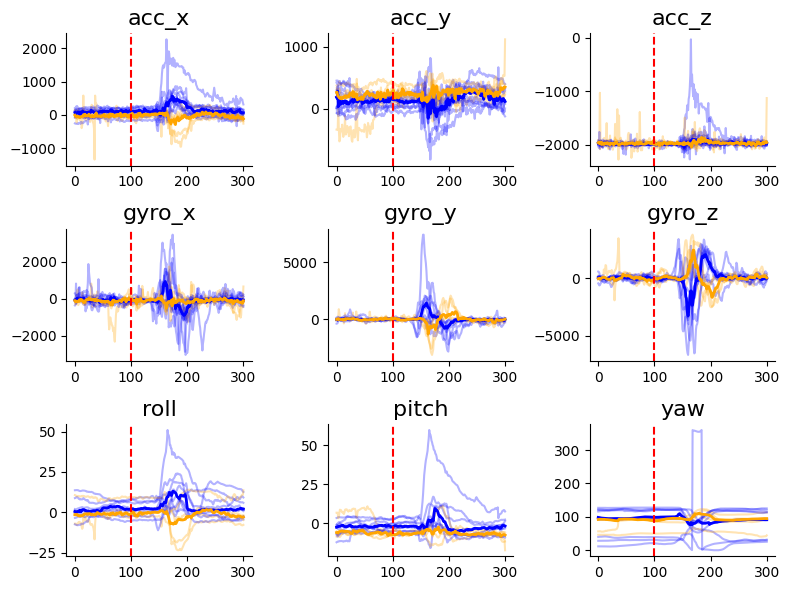

In [91]:
columns_to_plot = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'roll', 'pitch', 'yaw']
fig, axs = plt.subplots(figsize=(8, 6), nrows=3, ncols=3)
axs = axs.flatten()  # flatten the 3x3 array of axes for easy iteration
for ax, column_to_plot in zip(axs, columns_to_plot):
    plot_imu_panel(column_to_plot, ax)
plt.tight_layout()
plt.show()

Another optimization would be to plot the delta in roll, pitch and yaw for instance, or the derivative of these values

In [96]:
# add derivative values to these 9 columns
for column in columns_to_plot:
    final_df[column + '_derivative'] = final_df[column].diff().rolling(window=10).median()

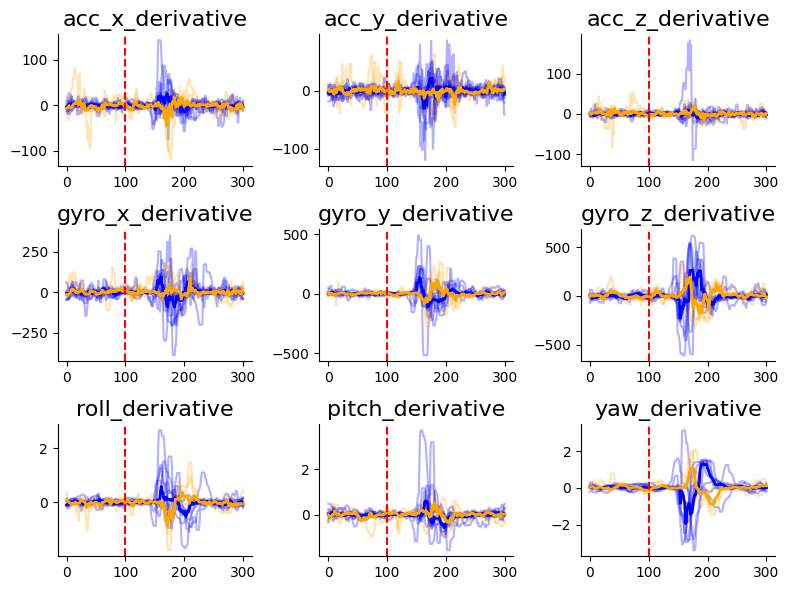

In [97]:
# remake the plot with the derivatives
fig, axs = plt.subplots(figsize=(8, 6), nrows=3, ncols=3)
axs = axs.flatten()  # flatten the 3x3 array of axes for easy iteration
for ax, column_to_plot in zip(axs, columns_to_plot):
    plot_imu_panel(column_to_plot + '_derivative', ax)
plt.tight_layout()
plt.show()

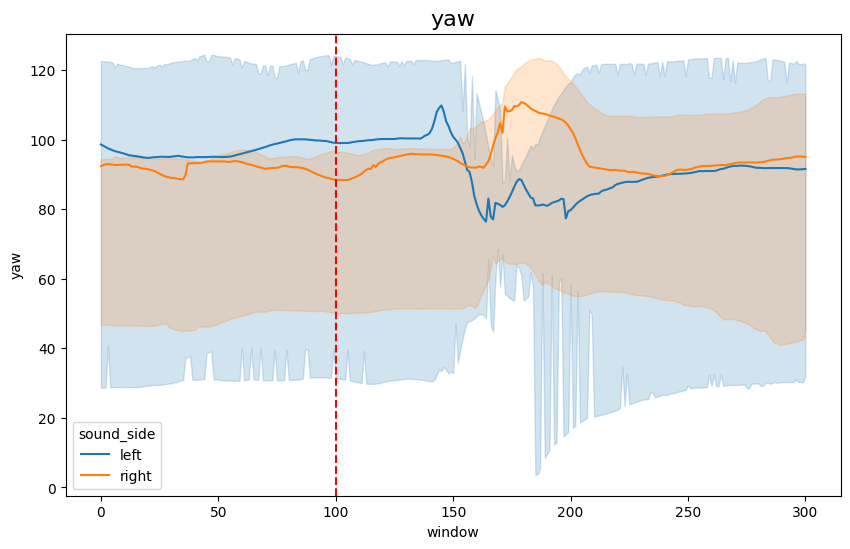

In [75]:
# plot with seaborn lines for each trial, colouring by sound_side, for a specific column
import seaborn as sns
import matplotlib.pyplot as plt

column_to_plot = "yaw"  # replace with the column you want to plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=final_df, x="window", y=column_to_plot, hue="sound_side", estimator="median")
# vertical line at window 100
plt.axvline(x=100, color='r', linestyle='--')
plt.title(f"{column_to_plot}", size=16)
plt.show()